# HealthConnect Clinic — Week 6

## Integration, Advanced Development & Model Validation

**Project:** HealthConnect Clinic Appointment No-Show Prediction  
**Track:** Data Science  

# 1. Week 5 → Week 6 Transition

## 1.1 Main Week 5 output 
During Week 5, the Data Science track moved from problem understanding into practical machine learning development. The main output was a prepared modelling dataset and an initial Logistic Regression classification model for predicting whether a patient would miss their appointment. After excluding cancelled appointments, the dataset contained 4,737 appointment records. The Week 5 workflow included data preparation, data quality checks, feature engineering and selection, train-test splitting, preprocessing, and baseline model development. The Logistic Regression model used a preprocessing pipeline that handled numerical feature scaling and categorical feature encoding before model training.


## 1.2 Most important Week 5 Result

The Week 5 Logistic Regression model produced the following baseline results:

- Accuracy: 61.39%
- Precision: 60.84%
- Recall: 68.87%
- F1-score: 64.60%
- ROC-AUC: 66.42%

The confusion matrix was:

```text
[[248, 215],
 [151, 334]]

The model correctly identified 334 no-show appointments, but missed 151 actual no-shows. It also incorrectly classified 215 attended appointments as no-shows.

Therefore, the Logistic Regression model provides a useful baseline benchmark, but its performance indicates that further investigation and improvement are required before considering it suitable for practical HealthConnect use.

## 1.3 Main issue or limitation

The main limitation identified from Week 5 is that the baseline model has only moderate predictive performance.

In particular, the model produces both:

False positives: patients predicted to miss their appointment who actually attended.
False negatives: patients predicted to attend who actually missed their appointment.

Understanding these errors is important because the purpose of the HealthConnect model is not simply to achieve a high accuracy score. The model should help the clinic identify patients who may require additional attention before their appointments.

Week 6 will therefore focus on understanding where the baseline model makes mistakes and identifying ways to improve the modelling approach without introducing data leakage.

## 1.4 Relevant track for Week 6 integration

The main cross-track dependency for the Data Science work is the Data Analytics track.

During Week 5, analytical findings highlighted relationships involving:

booking lead time,
previous no-show history,
distance to the clinic,
appointment type,
appointment timing, and
appointment day.

These findings are relevant to the Data Science model because they can guide feature review, error analysis, and feature refinement.

In Week 6, these analytical findings will be incorporated into the modelling process rather than being treated only as separate descriptive results.

## 1.5 What will be improved, integrated and validated

The Week 6 Data Science work will focus on the following activities:

1. Analyse the weaknesses of the Week 5 baseline model.
2. Investigate false positives and false negatives.
3. Identify patterns within model errors.
4. Review the features used by the baseline model.
5. Incorporate relevant findings from the Data Analytics track.
6. Refine or engineer features where there is a clear justification.
7. Develop at least one improved classification model.
8. Compare the improved model against the Week 5 Logistic Regression baseline.
9. Evaluate the models using appropriate classification metrics.
10. Examine confusion matrices and model errors.
11. Assess whether the improved model is more suitable for the HealthConnect problem.
12. Document modelling decisions, limitations, risks, and remaining issues.
13. Define the testing and validation requirements that will be carried into Week 7.

The overall objective is to move from the Week 5 baseline model toward a stronger and better validated candidate model for HealthConnect.

# 2. Week 5 dataset continuity and baseline data verification

## 2.1 Import libraries and load the Week 5 dataset

The Week 6 analysis continues directly from the dataset prepared during Week 5. No new dataset is introduced at this stage.

The processed HealthConnect dataset is loaded using pandas so that its structure, dimensions, variables and data quality can be verified before proceeding to baseline error analysis and model improvement.

In [3]:
import pandas as pd
import numpy as np

In [5]:
#Load the processed dataset created during Week 5

df = pd.read_csv("HealthConnect_Processed_Dataset.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


## 2.2 Verify dataset dimensions

The dimensions of the dataset are checked to confirm that the Week 5 processed dataset has been loaded correctly.

The expected dataset contains 4,737 records and 15 variables after the Week 5 preparation and feature engineering process.

In [6]:
print("Dataset shape:", df.shape)

Dataset shape: (4737, 15)


## 2.3 Inspect dataset variables

The dataset variables are reviewed to confirm that the expected demographic, appointment-related, historical and engineered features are available for the Week 6 modelling workflow.

In [7]:
print("Dataset columns:")
for column in df.columns:
    print("-", column)

Dataset columns:
- gender
- age
- age_group
- appointment_type
- booking_date
- appointment_date
- appointment_day
- appointment_time
- booking_lead_days
- previous_appointments
- previous_no_shows
- distance_to_clinic_km
- booking_lead_group
- distance_group
- no_show


## 2.4 Verify the target variable

The target variable for the Data Science task is no_show.

The target is binary:

- 0 represents an attended appointment.
- 1 represents a no-show appointment.

The target distribution is checked to confirm that the modelling population remains consistent with the Week 5 analysis.

In [9]:
print("No-show target distribution:")
print(df["no_show"].value_counts())

print("\nNo-show target percentage:")
print(df["no_show"].value_counts(normalize= True).mull(100)
      ,round(2))

No-show target distribution:
no_show
1    2423
0    2314
Name: count, dtype: int64

No-show target percentage:
no_show
1    51.150517
0    48.849483
Name: proportion, dtype: float64 2


## 2.5 Check for missing values

A missing value check is performed before continuing with model development.

The Week 5 preparation process addressed the missing values in the dataset. Therefore, the Week 6 dataset should contain no missing values in the variables being carried forward.

In [10]:
missing_values = df.isnull().sum()
print("Missing values by column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values by column:
gender                   0
age                      0
age_group                0
appointment_type         0
booking_date             0
appointment_date         0
appointment_day          0
appointment_time         0
booking_lead_days        0
previous_appointments    0
previous_no_shows        0
distance_to_clinic_km    0
booking_lead_group       0
distance_group           0
no_show                  0
dtype: int64

Total missing values: 0


## 2.6 Confirm identifier variables were removed

The patient and appointment identifiers used in the original dataset are not required for predicting appointment attendance behaviour.

During Week 5, appointment_id and patient_id were removed to reduce the risk of the model learning from identifiers rather than meaningful predictive information.

Their absence is verified before continuing with Week 6 modelling.

In [11]:
identifier_columns = ["appointment_id", "patient_id"]

for column in identifier_columns:
    print(f"{column}: {'Present' if column in df.columns 
                                else 'Not present'}")

appointment_id: Not present
patient_id: Not present


## 2.7 Review the modelling variables

The Week 5 modelling variables are reviewed to ensure that the Week 6 analysis continues with the same prediction framework.

The selected variables represent information that can reasonably be available before the appointment takes place. Variables associated with the appointment outcome or information that may only become available after prediction were excluded during Week 5 to reduce the risk of data leakage.

In [12]:
print("Variables available in the Week 5 processed dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Variables available in the Week 5 processed dataset:

1. gender
2. age
3. age_group
4. appointment_type
5. booking_date
6. appointment_date
7. appointment_day
8. appointment_time
9. booking_lead_days
10. previous_appointments
11. previous_no_shows
12. distance_to_clinic_km
13. booking_lead_group
14. distance_group
15. no_show


## 2.8 Final Week 5 dataset verification

The final verification confirms that the Week 5 processed dataset has been successfully carried forward into Week 6.

The checks confirm:

- 4,737 observations are available.
- 15 variables are present.
- The target variable no_show is available.
- The target contains both attended and no-show appointments.
- No missing values remain.
- Patient and appointment identifiers have been removed.

This establishes the dataset as the starting point for Week 6 baseline error analysis and model improvement.

In [15]:
print("==Week 5 Dataset Verification== ")
print("Dataset shape:", df.shape)
print("Target variable:", "no_show")
print("Target classes:", sorted(df["no_show"].unique()))
print("Total missing values:", df.isnull().sum().sum())
print("appointment_id present:", "appointment_id" in df.columns)
print("patient_id present:", "patient_id" in df.columns)

==Week 5 Dataset Verification== 
Dataset shape: (4737, 15)
Target variable: no_show
Target classes: [np.int64(0), np.int64(1)]
Total missing values: 0
appointment_id present: False
patient_id present: False


## 2.9 Week 5 dataset continuity statement

The Week 6 Data Science work continues from the processed dataset developed during Week 5. The dataset has been verified for its dimensions, variables, target distribution, missing values and identifier removal.

No new dataset has been introduced. The verified Week 5 dataset will therefore be used as the consistent foundation for reproducing the baseline model performance, analysing prediction errors and developing an improved model during Week 6.

The next section will establish the Week 5 Logistic Regression model as the baseline benchmark for the Week 6 improvement and validation process.

# 3. Re-establish the baseline

## 3.1 Define the modelling features and target

The Week 5 Logistic Regression model will be re-established as the baseline for Week 6.

The target variable is no_show, where:

- 0 = Attended
- 1 = No-Show

The baseline model uses the same 12 prediction features selected during Week 5. These features represent information that can reasonably be available before an appointment takes place.

Variables that could introduce information leakage or would not be reliably available at prediction time are excluded from the modelling features.

In [136]:
#Defining the target variable
target = "no_show"

#Defining the Week 5 modelling features
features = ["gender","age","age_group","appointment_type","appointment_day",
            "appointment_time","booking_lead_days","booking_lead_group",
            "previous_appointments", "previous_no_shows", 
            "distance_to_clinic_km", "distance_group"]
X = df[features]
y = df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (4737, 12)
Target shape: (4737,)


## 3.2 Separate numerical and categorical features

The baseline model contains both numerical and categorical variables.

Numerical variables will be standardised using StandardScaler, while categorical variables will be converted into numerical representations using one-hot encoding.

This preprocessing will be included inside a modelling pipeline to ensure that the same transformations are applied consistently to the training and testing data.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numerical_features = ["age", "booking_lead_days", "previous_appointments",
                      "previous_no_shows", "distance_to_clinic_km"]

categorical_features = ["gender", "age_group", "appointment_type",
                        "appointment_day","appointment_time",
                        "booking_lead_group", "distance_group"]

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Total features:", len(numerical_features) + len(categorical_features))

Numerical features: 5
Categorical features: 7
Total features: 12


## 3.3 Recreate the Week 5 train-test split

The same stratified 80:20 train-test split used during Week 5 is recreated using random_state=42.

Stratification is maintained so that the proportion of attended and no-show appointments remains similar between the training and testing datasets.

Using the same split allows the Week 6 improved model to be compared fairly against the Week 5 baseline.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
                                                    random_state=42,
                                                    stratify=y)

print ("X_train:", X_train.shape)
print ("X_test:", X_test.shape)
print ("y_train:", y_train.shape)
print ("y_test", y_test.shape)

X_train: (3789, 12)
X_test: (948, 12)
y_train: (3789,)
y_test (948,)


## 3.4 Verify the class distribution

The target distribution in the training and testing sets is checked to confirm that stratification was applied correctly.

Maintaining a similar class distribution is important because the baseline model performance will later be compared with the improved Week 6 model.

In [20]:
print("Training target distribution:")
print(y_train.value_counts())

print ("\nTesting target distribution:")
print(y_test.value_counts())

Training target distribution:
no_show
1    1938
0    1851
Name: count, dtype: int64

Testing target distribution:
no_show
1    485
0    463
Name: count, dtype: int64


## 3.5 Build the baseline preprocessing pipeline

A preprocessing pipeline is created to prepare the numerical and categorical variables for Logistic Regression.

Numerical variables are standardised using StandardScaler.

Categorical variables are transformed using one-hot encoding with handle_unknown="ignore" so that previously unseen categories in the testing data do not cause errors.

Keeping preprocessing inside the pipeline helps prevent inconsistent transformations and data leakage between the training and testing datasets.

In [28]:
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numerical_features), 
               ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)])

## 3.6 Re-establish the Week 5 Logistic Regression model

The Week 5 Logistic Regression model is reconstructed using the same modelling approach.

Logistic Regression is retained as the baseline because it provides a simple and interpretable reference model against which more advanced models can be evaluated in Week 6.

In [31]:
baseline_model = Pipeline(steps =[("preprocessor", preprocessor),
                                 ("Classifier", LogisticRegression(max_iter=1000,
                                                                   random_state=42))])

baseline_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['gender','age','age_group',...,'previous_no_shows', 'distance_to_clinic_km','distance_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rem

## 3.7 Generate baseline predictions

The trained baseline model is used to generate predictions for the unseen testing dataset.

Both the predicted class labels and predicted probabilities are generated. The class predictions will be used to calculate classification metrics and the confusion matrix, while the probabilities will be used to calculate ROC-AUC.

In [103]:
y_pred_baseline = baseline_model.predict(X_test)

y_prob_baseline = baseline_model.predict_proba(X_test) [:, 1]

print("Baseline predictions generated successfully.")
print("Number of predictions:", len(y_pred_baseline))

Baseline predictions generated successfully.
Number of predictions: 948


## 3.8 Evaluate the Week 5 baseline

The re-established baseline is evaluated using accuracy, precision, recall, F1-score and ROC-AUC.

These metrics provide a broader assessment than accuracy alone. In particular, recall is important because it measures how effectively the model identifies appointments that actually result in a no-show.

The Week 5 baseline results provide the benchmark for evaluating the improved model developed later in Week 6.

In [35]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)

baseline_accuracy = accuracy_score(y_test,y_pred_baseline)

baseline_precision = precision_score(y_test,y_pred_baseline)

baseline_recall = recall_score(y_test,y_pred_baseline)

baseline_f1 = f1_score(y_test,y_pred_baseline)

baseline_roc_auc = roc_auc_score(y_test,y_prob_baseline)


print("== Week 5 baseline performance ==")
print(f"Accuracy  : {baseline_accuracy:.4f}")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1-score  : {baseline_f1:.4f}")
print(f"ROC-AUC   : {baseline_roc_auc:.4f}")

== Week 5 baseline performance ==
Accuracy  : 0.6139
Precision : 0.6084
Recall    : 0.6887
F1-score  : 0.6460
ROC-AUC   : 0.6642


## 3.9 Baseline confusion matrix

The confusion matrix is examined to understand the types of errors produced by the baseline model.

The four outcomes are:

- True Negative (TN): Attended appointments correctly predicted as attended.
- False Positive (FP): Attended appointments incorrectly predicted as no-show.
- False Negative (FN): No-show appointments incorrectly predicted as attended.
- True Positive (TP): No-show appointments correctly predicted as no-show.

This error structure will form the basis of the Week 6 error analysis.

In [36]:
from sklearn.metrics import confusion_matrix

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

print("Baseline confusion matrix:")
print(cm_baseline)

Baseline confusion matrix:
[[248 215]
 [151 334]]


## 3.10 Interpret the baseline errors

The baseline confusion matrix shows that the model correctly identified 334 of the 485 actual no-show appointments.

However, 151 actual no-show appointments were incorrectly predicted as attended. These false negatives represent appointments where the model failed to identify a patient who eventually did not attend.

The model also incorrectly classified 215 attended appointments as no-shows. These false positives could result in unnecessary reminder or intervention actions.

The presence of both false negatives and false positives indicates that the baseline model requires further investigation before it can be considered suitable for operational use.

The Week 6 analysis will therefore focus on understanding these errors and identifying whether specific patient, appointment or behavioural characteristics are associated with incorrect predictions.

## 3.11 Save the baseline metrics for later comparison

The baseline performance metrics are stored in a dictionary so that they can be compared directly with the improved model developed later in Week 6.

The baseline will remain unchanged throughout the improvement process and will serve as the reference point for evaluating whether subsequent modelling decisions produce a meaningful improvement.

In [37]:
baseline_metrics = {"Accuracy": baseline_accuracy,"Precision": baseline_precision,
                    "Recall": baseline_recall,"F1-score": baseline_f1,"ROC-AUC": baseline_roc_auc}

baseline_metrics

{'Accuracy': 0.6139240506329114,
 'Precision': 0.6083788706739527,
 'Recall': 0.688659793814433,
 'F1-score': 0.6460348162475822,
 'ROC-AUC': 0.664224800160317}

## 3.12 Week 5 baseline re-establishment summary

The Week 5 Logistic Regression baseline has been successfully re-established using the verified Week 5 processed dataset.

The model achieved:

| Metric | Baseline |
|---|---:|
| Accuracy | 61.39% |
| Precision | 60.84% |
| Recall | 68.87% |
| F1-score | 64.60% |
| ROC-AUC | 66.42% |

The confusion matrix was:

```text
[[248, 215],
 [151, 334]]

# 4. Performing proper false-positive/false-negative error analysis

## 4.1 Examine the confusion matrix

The confusion matrix from the re-established Week 5 Logistic Regression model is examined to understand how the baseline model classified attended and no-show appointments.

The confusion matrix provides four possible outcomes:

- True Negative (TN): An attended appointment correctly predicted as attended.
- False Positive (FP): An attended appointment incorrectly predicted as a no-show.
- False Negative (FN): A no-show appointment incorrectly predicted as attended.
- True Positive (TP): A no-show appointment correctly predicted as a no-show.

Understanding these error types is important because the HealthConnect use case is not only concerned with overall predictive accuracy. The model should help the clinic identify appointments that may require additional intervention while limiting unnecessary interventions for patients who are likely to attend.

In [40]:
print("Baseline confusion matrix:")
print(cm_baseline)

Baseline confusion matrix:
[[248 215]
 [151 334]]


In [42]:
tn, fp, fn, tp = cm_baseline.ravel()

print("True negatives :", tn)
print("False positives:", fp)
print("False negatives:", fn)
print("True positives :", tp)

True negatives : 248
False positives: 215
False negatives: 151
True positives : 334


### Interpretation

The baseline model correctly identified 334 no-show appointments out of 485 actual no-shows, while 151 actual no-shows were missed.

Among the appointments that were actually attended, 248 were correctly classified as attended, while 215 were incorrectly flagged as no-shows.

This indicates that the baseline model has a meaningful ability to identify no-shows, as reflected by its recall of 68.87%, but it also produces a substantial number of both false negatives and false positives.

These errors will be investigated further in the following sections to determine whether they are concentrated within particular patient or appointment characteristics.

## 4.2 Identify false positives and false negatives

The baseline model produced both false-positive and false-negative predictions. These errors are important because they represent different types of prediction mistakes in the HealthConnect appointment no-show problem.

A false positive (FP) occurs when an appointment is actually attended but the model predicts a no-show. A false negative (FN) occurs when an appointment is actually a no-show but the model predicts attendance.

For HealthConnect, false negatives are particularly important because they represent no-show appointments that the model failed to identify. False positives are also important because they may result in unnecessary follow-up or reminder interventions for patients who were likely to attend.

In [52]:
#Creating a copy of the test-set features
error_analysis = X_test.copy()

#Adding the actual outcome
error_analysis["actual_no_show"] = y_test.values

#Adding the model`s predicted outcome
error_analysis["predicted_no_show"] = y_pred_baseline

#Classiying each prediction
error_analysis["prediction_result"] = np.select(
    [ 
        (error_analysis["actual_no_show"]==0) & (error_analysis["predicted_no_show"]==0),
        (error_analysis["actual_no_show"]==0) & (error_analysis["predicted_no_show"]==1),
        (error_analysis["actual_no_show"]==1) & (error_analysis["predicted_no_show"]==0),
        (error_analysis["actual_no_show"]==1) & (error_analysis["predicted_no_show"]==1)
    ],
    [ "True negative", "False positive", "False negative", "True positive"],  default="Unknown")

error_analysis.head()

,gender,age,age_group,appointment_type,appointment_day,appointment_time,booking_lead_days,booking_lead_group,previous_appointments,previous_no_shows,distance_to_clinic_km,distance_group,actual_no_show,predicted_no_show,prediction_result
2680,Female,24,18-24,Follow-up,Friday,Morning,24,15–30 days,2,0,2.4,0–5 km,1,0,False negative
191,Male,64,55-64,General Consultation,Saturday,Morning,29,15–30 days,1,0,12.6,11–15 km,0,0,True negative
2138,Male,18,18-24,Follow-up,Saturday,Afternoon,41,31–45 days,5,1,16.7,16–20 km,1,1,True positive
1005,Male,65,65+,Diagnostic Test,Friday,Morning,43,31–45 days,2,0,3.1,0–5 km,1,0,False negative
4594,Male,62,55-64,General Consultation,Friday,Afternoon,34,31–45 days,4,1,14.9,11–15 km,1,1,True positive


In [53]:
print("Prediction error summary:")
print(error_analysis["prediction_result"].value_counts())

Prediction error summary:
prediction_result
True positive     334
True negative     248
False positive    215
False negative    151
Name: count, dtype: int64


## 4.3 Creating separate false-positive and false-negative datasets

To investigate the baseline model's errors in greater detail, the false-positive and false-negative cases are separated from the complete test dataset.

This allows the characteristics of incorrectly classified appointments to be examined independently.

In [54]:
false_positives = error_analysis[ error_analysis["prediction_result"]== "False positive"].copy()
false_negatives = error_analysis[ error_analysis["prediction_result"]== "False negative"].copy()

print("Number of false positives:", len(false_positives))
print("Number of false negatives:", len(false_negatives))

Number of false positives: 215
Number of false negatives: 151


In [48]:
false_positives.head()

,gender,age,age_group,appointment_type,appointment_day,appointment_time,booking_lead_days,booking_lead_group,previous_appointments,previous_no_shows,distance_to_clinic_km,distance_group,actual_no_show,predicted_no_show,predicted_results
4239,Female,40,35-44,General Consultation,Sunday,Morning,41,31–45 days,3,0,6.7,6–10 km,0,1,False positive
3633,Female,55,55-64,General Consultation,Friday,Morning,31,31–45 days,4,1,10.3,11–15 km,0,1,False positive
1795,Male,60,55-64,Follow-up,Friday,Morning,46,46–60 days,1,0,13.0,11–15 km,0,1,False positive
4643,Male,39,35-44,General Consultation,Wednesday,Afternoon,40,31–45 days,1,0,12.6,11–15 km,0,1,False positive
3185,Female,20,18-24,General Consultation,Saturday,Afternoon,21,15–30 days,7,2,15.2,16–20 km,0,1,False positive


In [49]:
false_negatives.head()

,gender,age,age_group,appointment_type,appointment_day,appointment_time,booking_lead_days,booking_lead_group,previous_appointments,previous_no_shows,distance_to_clinic_km,distance_group,actual_no_show,predicted_no_show,predicted_results
2680,Female,24,18-24,Follow-up,Friday,Morning,24,15–30 days,2,0,2.4,0–5 km,1,0,False negative
1005,Male,65,65+,Diagnostic Test,Friday,Morning,43,31–45 days,2,0,3.1,0–5 km,1,0,False negative
907,Male,19,18-24,Follow-up,Monday,Morning,11,8–14 days,1,0,23.8,21–30 km,1,0,False negative
675,Male,26,25-34,General Consultation,Wednesday,Morning,19,15–30 days,2,0,14.9,11–15 km,1,0,False negative
876,Female,76,65+,Follow-up,Friday,Morning,9,8–14 days,5,2,6.7,6–10 km,1,0,False negative


## 4.4 Compare correct and incorrect predictions

The characteristics of correctly and incorrectly classified appointments are compared to determine whether the baseline model performs differently across different types of appointments.

The analysis focuses on the main variables used by the model, including booking lead time, previous appointment history, distance to the clinic, appointment type, age group, appointment day, and appointment time.

This comparison is intended to identify areas where the baseline model may have difficulty distinguishing between attended and no-show appointments.

In [55]:
#Comparing the average numerical characteristics
numerical_error_features = ["age", "booking_lead_days", "previous_appointments", 
                            "previous_no_shows", "distance_to_clinic_km"]

error_analysis.groupby("prediction_result")[numerical_error_features].mean().round(2)

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km
prediction_result,,,,,
False negative,48.34,17.58,2.89,0.36,9.08
False positive,48.89,39.11,3.13,0.69,11.49
True negative,50.16,13.29,2.94,0.33,9.02
True positive,47.55,43.39,3.23,0.73,11.02


In [56]:
pd.crosstab(error_analysis["prediction_result"], error_analysis["actual_no_show"])

actual_no_show,0,1
prediction_result,,
False negative,0,151
False positive,215,0
True negative,248,0
True positive,0,334


### Interpretation 

The numerical error analysis shows differences between correctly and incorrectly classified appointments.

Age shows relatively similar average values across the four prediction groups, suggesting that age alone does not appear to be a major source of prediction error.

Booking lead time shows a more noticeable difference. False negatives have a lower average booking lead time (17.58 days) than true positives (43.39 days). This suggests that no-shows occurring after shorter booking lead times may be more difficult for the baseline model to identify.

Previous no-show history also differs between the groups. False negatives have an average of 0.36 previous no-shows, compared with 0.73 among true positives. This suggests that patients with a stronger previous no-show history are easier for the baseline model to identify, while some no-shows with limited previous no-show history are more difficult to detect.

Distance to the clinic also shows some variation, with false negatives having a lower average distance (9.08 km) than true positives (11.02 km). This indicates that distance may contribute to differences in prediction patterns, although the comparison does not establish a causal relationship.

These findings suggest that booking lead time, previous no-show history, and distance may warrant further investigation during feature refinement.

# 4.5 Analyse errors by key features

### 4.5.1 Prediction errors by booking lead group

Booking lead time was identified during the Week 5 exploratory analysis as an important factor associated with appointment attendance.

The distribution of false positives and false negatives across booking lead-time groups is therefore examined to determine whether the baseline model struggles with appointments booked within particular time ranges.

In [58]:
pd.crosstab(error_analysis["booking_lead_group"], error_analysis["prediction_result"])


prediction_result,False negative,False positive,True negative,True positive
booking_lead_group,,,,
0–7 days,31,2,84,2
15–30 days,69,37,86,36
31–45 days,16,100,14,119
46–60 days,0,71,0,172
8–14 days,35,5,64,5


#### Interpretation

The prediction errors vary across the different booking lead-time groups.

The 15–30 day and 31–45 day groups show the highest overall error rates, at approximately 46.5% each. The 31–45 day group contains the largest number of false positives, with 100 attended appointments incorrectly classified as potential no-shows.

The 15–30 day group contains the largest number of false negatives, with 69 actual no-show appointments incorrectly classified as attended.

The 46–60 day group has no false negatives, indicating that the baseline model identified all actual no-shows in this group. However, it also produced 71 false positives, meaning that a substantial number of attended appointments were incorrectly classified as no-shows.

Overall, the results suggest that booking lead time may be associated with differences in the baseline model's prediction errors. In particular, the 15–45 day booking ranges warrant further investigation during feature refinement. These findings will later be considered together with the Data Analytics findings before making final feature engineering decisions.

### 4.5.2 Prediction errors by previous no-show history

Previous no-show history was identified as an important predictor during the Week 5 analysis.

The baseline model's errors are therefore examined according to the number of previous no-shows to determine whether patients with different attendance histories are being classified differently.

In [63]:
pd.crosstab(error_analysis["previous_no_shows"], error_analysis["prediction_result"])

prediction_result,False negative,False positive,True negative,True positive
previous_no_shows,,,,
0,106,110,176,151
1,37,70,63,132
2,7,28,8,42
3,1,6,1,8
4,0,1,0,1


#### Interpretation

The prediction errors vary according to patients' previous no-show history.

Patients with no previous no-shows account for the largest number of false negatives and false positives, with 106 false negatives and 110 false positives. This group also represents the largest number of observations in the analysis.

For patients with one previous no-show, the model produced 37 false negatives and 70 false positives. For patients with two previous no-shows, the model produced 7 false negatives and 28 false positives.

The results suggest that previous no-show history may help the model distinguish patients with different attendance patterns. In particular, the number of false negatives decreases as previous no-show history increases, while the number of true positives becomes relatively larger.

However, the groups with three and four previous no-shows contain very few observations. Therefore, their error rates should not be used to draw strong conclusions.

Overall, the analysis indicates that previous no-show history is relevant to prediction performance, but the baseline model still produces both false positives and false negatives across different attendance-history groups. This feature will therefore be considered during the feature refinement stage.

In [66]:
error_analysis["previous_no_show_group"] = np.where(error_analysis["previous_no_shows"]== 0,
                                                    "0 previous_no_shows",
                                                    "1+ previous_no_shows")

pd.crosstab(error_analysis["previous_no_show_group"], error_analysis["prediction_result"])

prediction_result,False negative,False positive,True negative,True positive
previous_no_show_group,,,,
0 previous_no_shows,106,110,176,151
1+ previous_no_shows,45,105,72,183


#### Interpretation

The detailed error analysis shows that prediction errors occur across all levels of previous no-show history.

Patients with no previous no-shows produced 106 false negatives and 110 false positives, while patients with one or more previous no-shows produced 45 false negatives and 105 false positives.

The grouped analysis shows that patients with one or more previous no-shows had 183 true positives compared with 45 false negatives. This indicates that the baseline model identifies a larger proportion of actual no-shows among patients who have a previous no-show history.

However, the model also produced 105 false positives in the 1+ previous no-shows group. Therefore, previous no-show history helps distinguish higher-risk patients, but it does not completely prevent incorrect predictions.

The detailed groups containing three or four previous no-shows have very few observations and should therefore not be used to draw strong conclusions.

Overall, previous no-show history appears to be an important feature for prediction performance. It will be retained for consideration during feature refinement, while the remaining error patterns will be examined across the other key features.

### 4.5.3 Prediction errors by appointment type

Appointment type may influence attendance behaviour because different appointment categories can have different levels of urgency, scheduling flexibility, and patient commitment.

The baseline model's prediction errors are therefore examined across appointment types.

In [67]:
pd.crosstab(error_analysis["appointment_type"], error_analysis["prediction_result"])

prediction_result,False negative,False positive,True negative,True positive
appointment_type,,,,
Diagnostic Test,20,33,20,42
Follow-up,48,60,63,108
General Consultation,57,81,121,136
Specialist Consultation,26,41,44,48


#### Interpretation

The prediction errors occur across all appointment types, indicating that the baseline model does not perform equally well for every type of appointment.

The Diagnostic Test group has the highest overall error rate at approximately 46.1%, followed by Specialist Consultation at approximately 42.1%. This suggests that the baseline model may have greater difficulty distinguishing between no-shows and attended appointments for these appointment types.

General Consultation has the largest number of prediction errors, with 57 false negatives and 81 false positives. However, this group also contains the largest number of observations, so the higher number of errors is partly influenced by its larger sample size.

The Follow-up group has a lower error rate of approximately 38.7%, although it still contains a substantial number of false positives and false negatives.

Overall, appointment type appears to be relevant to the distribution of prediction errors. The relatively higher error rates observed for Diagnostic Test and Specialist Consultation appointments suggest that appointment type should be retained and considered during feature refinement. However, the results alone do not establish that appointment type causes prediction errors, so further evaluation will be required when comparing the improved model with the baseline.

### 4.5.4 Prediction errors by age group

Age group is examined to determine whether the baseline model performs consistently across different patient age categories.

In [68]:
pd.crosstab(error_analysis["age_group"], error_analysis["prediction_result"])

prediction_result,False negative,False positive,True negative,True positive
age_group,,,,
18-24,21,20,32,42
25-34,16,34,34,52
35-44,31,35,35,55
45-54,27,37,35,49
55-64,22,38,35,73
65+,34,51,77,63


#### Interpretation

The prediction errors vary across the different age groups, indicating that the baseline model does not perform equally across all age categories.

The 45–54 age group has the highest overall error rate at approximately 43.2%, followed by the 35–44 group at approximately 42.3%. These groups therefore show relatively higher levels of misclassification compared with the other age groups.

The 65+ group has the largest number of prediction errors, with 34 false negatives and 51 false positives. However, this group also contains the largest number of observations, so the higher number of errors is partly influenced by its larger sample size.

The 65+ group also has 77 true negatives, indicating that the model correctly classified many attended appointments in this age group. Nevertheless, the 51 false positives show that the model also incorrectly classified a substantial number of attended appointments as potential no-shows.

The younger age groups, particularly 18–24 and 25–34, have lower overall error rates than the 35–54 groups. However, errors are still present across all age categories.

Overall, age group appears to be associated with differences in the distribution of prediction errors, although the error analysis alone does not establish that age causes these errors. Age group will therefore be retained for consideration during feature refinement, while the remaining error patterns are examined across other key features.

### 4.5.5 Prediction errors by appointment day

Appointment day is examined to determine whether prediction errors are concentrated on particular days of the week.

In [71]:
pd.crosstab(error_analysis["appointment_day"], error_analysis["prediction_result"])

prediction_result,False negative,False positive,True negative,True positive
appointment_day,,,,
Friday,32,32,36,40
Monday,23,21,33,49
Saturday,23,25,38,44
Sunday,20,44,35,49
Thursday,20,25,31,43
Tuesday,14,31,42,45
Wednesday,19,37,33,64


#### Interpretation

The prediction errors vary across the different appointment days, indicating that the baseline model does not perform equally across all days of the week.

Friday has the highest overall error rate at approximately 45.7%, followed by Sunday at approximately 43.2%. The Friday group contains 32 false negatives and 32 false positives, while Sunday has 20 false negatives and 44 false positives.

Tuesday has the lowest overall error rate at approximately 34.1%, followed by Monday at approximately 34.9%. However, prediction errors are still present across all appointment days.

Wednesday has the highest number of true positives, with 64 actual no-show appointments correctly identified by the model. This suggests that the model is able to identify many no-shows occurring on Wednesday, although false negatives and false positives are still present.

Overall, appointment day shows some variation in the distribution of prediction errors, particularly for Friday and Sunday. However, the differences are not sufficient on their own to conclude that appointment day is a major source of model error. Appointment day will therefore be retained as a potential feature while the remaining error patterns are examined.

### 4.5.6 Prediction errors by appointment time

Appointment time is examined to determine whether the baseline model has greater difficulty classifying appointments scheduled during particular time periods.

In [72]:
pd.crosstab(error_analysis["appointment_time"], error_analysis["prediction_result"])

prediction_result,False negative,False positive,True negative,True positive
appointment_time,,,,
Afternoon,61,83,100,138
Evening,23,32,33,61
Morning,67,100,115,135


#### Interpretation

The prediction errors vary somewhat across the different appointment-time groups, although the differences are relatively modest.

The Morning group has the highest overall error rate at approximately 40.0%, with 67 false negatives and 100 false positives. This indicates that the baseline model makes a relatively high proportion of incorrect predictions for morning appointments.

The Afternoon group has an error rate of approximately 37.7%, with 61 false negatives and 83 false positives. The Evening group has the lowest error rate at approximately 36.9%, although prediction errors are still present.

The Morning group also contains the largest number of observations, which contributes to its higher absolute number of false negatives and false positives.

Overall, appointment time shows some variation in the distribution of prediction errors, with morning appointments showing the highest error rate. However, the differences between the groups are relatively small, so appointment time does not appear to be one of the strongest sources of baseline model error based on this analysis alone. It will therefore be retained as a potential feature while the remaining error patterns are examined.

### 4.5.7 Prediction errors by distance group

Distance to the clinic was examined during Week 5 because longer travel distances may create additional barriers to appointment attendance.

The distribution of false positives and false negatives across distance groups is therefore examined.

In [73]:
pd.crosstab(error_analysis["distance_group"], error_analysis["prediction_result"])

prediction_result,False negative,False positive,True negative,True positive
distance_group,,,,
0–5 km,47,31,66,63
11–15 km,38,55,48,77
16–20 km,14,26,20,37
21–30 km,5,20,15,29
31–50 km,1,6,0,8
6–10 km,46,77,99,120


#### Interpretation

The prediction errors vary across the different distance-to-clinic groups, indicating that the baseline model does not perform equally across all distance categories.

The 11–15 km group has a relatively high error rate of approximately 42.7%, while the 16–20 km group has an error rate of approximately 41.2%. These groups therefore show relatively higher levels of misclassification compared with several of the other distance groups.

The 31–50 km group has the highest error rate at approximately 46.7%. However, this group contains only 15 observations, so the result should be interpreted with caution and should not be used as strong evidence of poor model performance for patients living farther from the clinic.

The 6–10 km group contains the largest number of observations and has the highest number of false positives, with 77 attended appointments incorrectly classified as potential no-shows.

Overall, distance group shows some variation in the distribution of prediction errors, particularly in the 11–20 km ranges. However, the smaller groups have limited observations, which reduces the strength of conclusions that can be drawn from them.

Distance to the clinic will therefore be retained as a potential feature for further evaluation and feature refinement, while avoiding causal conclusions based on the error analysis alone.

## 4.6 Identify initial error patterns

The error analysis across the key features shows that the baseline Logistic Regression model makes prediction errors across a range of patient and appointment characteristics.

One of the clearest patterns is observed for booking lead time. The 15–30 day and 31–45 day groups have the highest overall error rates, at approximately 46.5% and 46.6%, respectively. The 15–30 day group contains the largest number of false negatives, while the 31–45 day group contains the largest number of false positives. This suggests that the relationship between booking lead time and no-show risk may not be fully captured by the baseline model.

Previous no-show history also shows an important error pattern. Patients with one or more previous no-shows have 183 true positives compared with 45 false negatives, indicating that the model is better able to identify no-shows among patients with previous no-show history. However, 105 false positives remain in this group, showing that previous no-show history does not completely distinguish between patients who will attend and those who will not.

Appointment type also shows variation in prediction errors. Diagnostic Tests have the highest error rate at approximately 46.1%, followed by Specialist Consultations at approximately 42.1%. General Consultations have the largest absolute number of errors, although this group also contains the largest number of observations.

Age groups show moderate variation in error rates, with the highest error rates observed among patients aged 45–54 and 35–44. Appointment day also shows some variation, with Friday and Sunday having relatively higher error rates. However, errors occur across all appointment days.

Appointment time shows smaller differences between groups, with morning appointments having the highest error rate at approximately 40.0%. Distance to the clinic also shows some variation, particularly among the 11–15 km and 16–20 km groups. However, the 31–50 km group contains only 15 observations and should therefore not be used as strong evidence of a distance-related error pattern.

Overall, the error analysis suggests that booking lead time and previous no-show history are particularly important areas for further investigation. Appointment type, age group and distance also show potentially relevant patterns, while appointment day and appointment time show more modest differences. These findings will guide the feature-refinement stage of the Week 6 modelling process.

## 4.7 Baseline model weaknesses

The baseline Logistic Regression model provides a useful starting point for predicting appointment no-shows, but the evaluation results indicate several areas where improvement is required.

First, the model has moderate overall predictive performance, with an accuracy of 61.39%, F1-score of 64.60% and ROC-AUC of 0.6642. These results indicate that the model has some ability to distinguish between no-show and attended appointments, but its predictive discrimination remains limited.

Second, the model produces a substantial number of false positives. Of the 948 test observations, 215 attended appointments were incorrectly classified as potential no-shows. In a HealthConnect setting, this could result in unnecessary follow-up or intervention for patients who were likely to attend their appointments.

Third, the model produces 151 false negatives, representing actual no-show appointments that were incorrectly classified as attended. These errors are important because failing to identify a patient at risk of missing an appointment may reduce the usefulness of the model for targeted no-show prevention.

Fourth, the error analysis shows that model performance varies across different patient and appointment characteristics. In particular, booking lead-time groups showed relatively high error rates in the 15–30 day and 31–45 day ranges. Previous no-show history also showed a clear difference in the distribution of true positives and false negatives. Additional variation was observed across appointment type, age group, appointment day, appointment time and distance group.

Fifth, the Logistic Regression model may not fully capture more complex relationships between the predictors and appointment attendance. The observed error patterns suggest that some features may interact with appointment characteristics or may have non-linear relationships with no-show risk. This provides a justification for comparing the baseline model with alternative classification approaches during Week 6.

Finally, the current feature representation may also limit predictive performance. Some variables are represented using both continuous and grouped forms, such as booking lead time and distance to the clinic. Rather than removing these features based only on the error analysis, their representations will be evaluated during feature refinement to determine whether alternative or additional feature engineering improves model performance.

Overall, the baseline model is suitable as a reference point for Week 6 but is not yet sufficient to recommend for operational use. The main improvement priorities are to reduce false positives and false negatives, investigate the error patterns identified above, refine the representation of important features, and evaluate alternative classification models using appropriate validation metrics.

# 5. Integrate the Data Analytics findings

## 5.1 Cross-Track Handoff: Data Analytics → Data Science

As part of the Week 6 cross-track integration requirement, the Data Science track received a validated findings package from the Data Analytics track.

The Data Analytics findings were calculated from the full HealthConnect dataset (n = 5,000), cross-checked against the Data Dictionary, and supported by stability checks across H1 and H2 2025 where applicable.

The purpose of this handoff was to provide evidence that could support:

- interpretation of the baseline model errors;
- identification of important predictors of no-show behaviour;
- feature refinement;
- investigation of potential interaction effects; and
- further model validation.

The Data Analytics track specifically requested the Data Science track's model error patterns, particularly false positives and false negatives, so that elevated-error segments could be investigated further using targeted validation.

## 5.2 Key Data Analytics Findings relevant to Data Science

The Data Analytics findings identified booking lead time and previous no-show history as the strongest predictors of no-show behaviour.

Booking lead time showed a clear increase in no-show rates:

- 0–7 days: 27.81%
- 8–14 days: 33.55%
- 15–30 days: 43.21%
- 31–45 days: 53.82%
- 46–60 days: 67.69%

The Data Analytics track identified booking lead time as the strongest single predictor in the dataset. The pattern was stable across H1/H2 2025 for four of the five groups, while the 8–14 day group showed greater instability and should therefore be interpreted cautiously.

Previous no-show history also showed a strong increasing pattern. The no-show rate increased from 43.51% for patients with no previous no-shows to 67.95% for patients with three previous no-shows. However, the groups with four and five previous no-shows contained very few observations and were unstable. The Data Analytics track therefore recommended treating these values as a combined "3+" group.

Distance to the clinic showed a moderate relationship with no-show behaviour, with higher no-show rates at greater distances. Missing-distance records had a no-show rate of 52.22%, suggesting that the missingness was not concentrated in an unusual risk group.

Appointment type, age group, appointment day, and appointment time showed weaker relationships with no-show behaviour and were not identified as primary predictors.

The Data Analytics track also identified a potentially useful relationship between booking lead time and previous no-show history. The combined pattern suggested that the effects of these two variables were largely additive rather than strongly multiplicative.

Reminder channel showed a moderate association with no-show behaviour, with SMS having the lowest observed no-show rate among the reminder categories. However, its suitability as a prediction feature depends on when the prediction is intended to be made.

Cancellations and no-shows were also found to behave differently across booking lead-time groups, supporting the decision to treat cancellations separately from the no-show prediction target.

## 5.3 Comparison between Data Analytics findings and Data Science error analysis

The Data Analytics findings were compared with the Data Science baseline model error analysis performed in Step 4.

The two tracks showed several important areas of agreement.

### Booking lead time

Data Analytics identified booking lead time as the strongest single predictor of no-show behaviour, with no-show rates increasing substantially as booking lead time increased.

The Data Science error analysis also identified booking lead time as an important source of model errors. The 15–30 day and 31–45 day groups had the highest observed model error rates, at approximately 46.5% and 46.6%, respectively.

The 15–30 day group produced the largest number of false negatives (69), while the 31–45 day group produced the largest number of false positives (100).

This agreement between the two tracks indicates that booking lead time should receive particular attention during the next feature-refinement stage.

### Previous no-show history

Data Analytics identified previous no-show history as another strong predictor. No-show rates increased progressively from patients with no previous no-shows to patients with three previous no-shows.

The Data Science error analysis also showed that previous no-show history was relevant to model performance. Among patients with one or more previous no-shows, the baseline model correctly identified 183 no-shows but still produced 45 false negatives and 105 false positives.

This suggests that previous no-show history contains useful predictive information, while also indicating that the baseline model does not fully capture all cases.

### Distance

Data Analytics identified distance as a moderate signal. Data Science also observed variation in error rates across distance groups, with some middle-distance groups showing elevated error rates.

However, the Data Science analysis did not provide sufficient evidence to conclude that distance is a dominant source of model error. It will therefore be treated as a secondary candidate during feature refinement.

### Appointment type

Data Analytics classified appointment type as a relatively weak signal overall. Data Science nevertheless observed differences in model error rates across appointment types, with Diagnostic Tests showing the highest error rate at approximately 46.1% and Specialist Consultations at approximately 42.1%.

This suggests that appointment type may contribute to model performance, but the cross-track evidence does not support treating it as a primary predictor.

### Age, appointment day and appointment time

Data Analytics found relatively weak signals for age group, appointment day and appointment time.

The Data Science error analysis also found variation across these variables, but the differences were generally modest compared with the stronger patterns observed for booking lead time and previous no-show history.

These variables therefore remain lower-priority areas for further investigation.

### Overall cross-track agreement

The strongest agreement between the two tracks is observed for:

1. booking lead time;
2. previous no-show history; and
3. to a lesser extent, distance.

The findings provide evidence for focusing the next modelling stage on these areas rather than making broad feature changes based only on isolated error groups.

## 5.4 Dataset scope and interpretation

An important consideration when integrating the two tracks is that the Data Analytics findings were calculated using the full HealthConnect dataset of 5,000 records.

The Data Science modelling workflow excluded cancelled appointments and therefore used 4,737 records for the no-show prediction task.

As a result, the descriptive no-show rates reported by Data Analytics should not be interpreted as identical to the model error rates calculated by Data Science.

The Data Analytics findings are used as cross-track evidence about patterns in the overall dataset, while the Data Science error analysis evaluates model performance on the modelling population after the cancellation records were excluded.

This distinction is important when comparing percentages across the two tracks and helps ensure that the integrated findings are interpreted within their appropriate analytical context.

## 5.5 Information received from Data Analytics

The Data Science track received the following information from the Data Analytics track:

- validated no-show rates by booking lead-time group,
- validated no-show rates by previous no-show history,
- analysis of appointment type, age group, appointment day and appointment time,
- distance-to-clinic analysis,
- reminder-channel analysis,
- booking lead time × previous no-show interaction analysis,
- cancellation versus no-show behaviour,
- waiting-time analysis,
- data-quality and sample-size considerations;
- H1/H2 stability information for selected findings, and
- recommendations regarding important and lower-priority features.

The most important information for Data Science was the identification of booking lead time and previous no-show history as strong predictors, together with the recommendation to treat rare previous-no-show values of 4 and 5 as a combined 3+ category.

## 5.6 Information provided by Data Science to Data Analytics

The Data Science track provided model error-analysis findings from the Week 6 baseline model.

The baseline model produced:

- Accuracy: 61.39%
- Precision: 60.84%
- Recall: 68.87%
- F1-score: 64.60%
- ROC-AUC: 0.6642

The confusion matrix contained:

- True Negatives: 248
- False Positives: 215
- False Negatives: 151
- True Positives: 334

The Data Science track then investigated the distribution of these errors across relevant patient and appointment characteristics.

The main findings provided to Data Analytics were:

- elevated error rates in the 15–30 and 31–45 day booking-lead groups;
- 69 false negatives in the 15–30 day group;
- 100 false positives in the 31–45 day group;
- substantial errors among patients with zero previous no-shows;
- continued false positives and false negatives among patients with previous no-show history;
- elevated error rates for some appointment types;
- moderate variation in errors across age groups;
- some variation across appointment days and appointment times; and
- variation across distance groups, with caution required for the smallest distance groups.

These findings were provided so that Data Analytics could investigate whether the observed error patterns are stable across time periods and whether segment-level sample sizes are sufficient to support further conclusions.

## 5.7 Requested validation from Data Analytics

Based on the Data Science error analysis, the following areas were identified for possible targeted validation by the Data Analytics track:

1. Booking lead-time groups
   - Validate the elevated model-error patterns observed in the 15–30 and 31–45 day groups.
   - Pay particular attention to the false-negative concentration in the 15–30 day group and false-positive concentration in the 31–45 day group.

2. Previous no-show history
   - Investigate whether the error patterns differ consistently between patients with zero previous no-shows and those with one or more previous no-shows.

3. 8–14 day lead-time stability
   - Review the stability of this group because the Data Analytics handoff identified a relatively large H1/H2 difference.

4. Segment sample sizes
   - Confirm that groups with apparently high error rates have sufficient observations to support interpretation.

5. Time-split stability
   - Where appropriate, determine whether the observed patterns remain consistent across different time periods.

The purpose of this validation is not to replace the Data Science model evaluation, but to determine whether the observed error patterns represent stable characteristics of the dataset or are partly influenced by sample size or temporal variation.

## 5.8 Cross-Track integration activity

The Data Analytics findings were integrated into the Data Science workflow by comparing the validated analytical findings with the baseline model's false-positive and false-negative error patterns.

This integration produced three main outcomes:

1. Priority alignment
   - Booking lead time and previous no-show history were confirmed as the highest-priority variables for further Data Science investigation.

2. Error-focused investigation
   - The Data Science error analysis was used to identify specific booking-lead and patient-history groups where model errors were concentrated.

3. Targeted validation request
   - The identified error segments were communicated back to Data Analytics for targeted validation of temporal stability and sample-size adequacy.

The integration therefore influenced the next modelling stage while maintaining the separation between Data Analytics validation and Data Science model development.

## 5.9 What changed as a result of cross-track integration?

The Data Analytics findings changed the focus of the Data Science workflow from general model improvement to targeted investigation of specific predictive factors.

Before integration, the Data Science track identified model weaknesses primarily from the baseline error analysis.

After integration, the error patterns could be interpreted alongside validated dataset-level findings from Data Analytics.

The combined evidence strengthened the case for prioritising:

- booking lead time;
- previous no-show history;
- the relationship between these two variables; and
- distance as a secondary factor.

It also provided evidence for treating rare previous-no-show values cautiously and for avoiding unnecessary prioritisation of weak variables such as appointment time.

These findings will be used in Step 6 to test specific feature refinements. No feature was changed solely on the basis of the Data Analytics findings at this stage; the proposed changes will be evaluated empirically in the next step.

## 5.10 Interpretation and Conclusion

The cross-track integration demonstrated meaningful collaboration between the Data Analytics and Data Science tracks.

Data Analytics provided validated evidence showing that booking lead time and previous no-show history are the strongest predictors of no-show behaviour, while distance provides a moderate signal and several other variables show weaker relationships.

Data Science compared these findings with the baseline model's error patterns and found strong agreement, particularly for booking lead time and previous no-show history.

The baseline model showed substantial errors across several booking lead-time groups, with the 15–30 and 31–45 day groups requiring particular attention. Previous no-show history also remained relevant to model performance.

The integration therefore provided a stronger evidence base for the next modelling stage than either track could provide independently.

Data Science has provided its false-positive and false-negative findings back to Data Analytics and requested targeted validation of the most important error segments, including time-split stability and segment-level sample sizes.

Overall, the cross-track integration has been completed and has produced clear, evidence-based priorities for Step 6: Feature Refinement.

# 6. Refine features

## 6.1 Review current baseline features

In [80]:
print("Current baseline features:")
print(features)

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nFeature count:")
print(len(features))

Current baseline features:
['gender', 'age', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'booking_lead_days', 'booking_lead_group', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km', 'distance_group']

Numerical features:
['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km']

Categorical features:
['gender', 'age_group', 'appointment_type', 'appointment_day', 'appointment_time', 'booking_lead_group', 'distance_group']

Feature count:
12


## 6.2 Identify features for refinement

The baseline Logistic Regression model established a useful reference point for predicting appointment no-shows. Based on the Data Analytics findings and the false-positive/false-negative error analysis conducted in Step 4, the next stage is to refine the feature representation before testing a Random Forest model.

The feature refinement will focus on improving the representation of variables that showed stronger predictive or error-related patterns, while avoiding unnecessary feature expansion.

### Features to retain

The following baseline features will initially be retained:

* booking_lead_days — showed the strongest relationship with no-show behaviour in the Data Analytics findings.
* booking_lead_group — captures differences across booking lead-time intervals.
* previous_no_shows — showed a meaningful relationship with no-show behaviour and was relevant to the error analysis.
* previous_appointments — retained as an existing patient-history variable.
* distance_to_clinic_km — showed moderate variation across no-show behaviour and error groups.
* distance_group — retained to test whether grouped distance information provides additional value.
* age and age_group — retained initially so that both continuous and grouped age representations can be evaluated.
* appointment_type — retained because differences were observed across appointment types.
* appointment_day — retained for comparison even though the observed differences were relatively modest.
* gender — retained initially and evaluated empirically rather than removed without testing.

### Features to refine

The following refinement will be tested:

1. previous_no_shows will also be represented as a grouped categorical feature:

   * 0
   * 1
   * 2
   * 3+

   The 3+ category combines the very small groups with three, four and five previous no-shows to provide a more stable representation.

2. The interaction between booking lead time and previous no-shows will be considered as a candidate refinement because the Data Analytics findings indicated that the combination of these two variables may provide additional information beyond their individual effects.

### Feature considered for removal

appointment_time will be treated as a candidate for removal because the Data Analytics analysis showed very small differences in no-show rates across morning, afternoon and evening appointments.

However, this feature will not be removed solely on the basis of the descriptive analysis. Its removal will be evaluated by comparing model performance with and without the feature.

### Features not reintroduced

reminder_sent, reminder_channel, waiting_time_minutes and appointment_outcome will not be reintroduced at this stage because they were excluded from the baseline modelling design due to prediction-time and potential data-leakage considerations.

### Objective of step 6

The objective is therefore to create a small number of justified feature refinements and determine empirically whether they improve the Logistic Regression baseline.

No Random Forest model will be developed during this step. The Random Forest will be introduced in Step 7 after the refined feature set has been evaluated.


## 6.3 Creating refined features

### 6.3.1 Group previous no-shows

The previous_no_shows variable is retained in its original numerical form because it contains useful patient-history information. In addition, a grouped categorical representation will be created to reduce the influence of very small categories.

The values will be grouped as follows:

* 0 → 0
* 1 → 1
* 2 → 2
* 3, 4, and 5 → 3+

This refinement is based on the Data Analytics finding that the categories representing three or more previous no-shows contain relatively few observations, particularly at the highest values. Combining these categories provides a more stable representation while retaining the distinction between patients with no previous no-shows, one, two, and three or more previous no-shows.

The original previous_no_shows variable will be retained so that the refined representation can be evaluated against the baseline rather than assuming that the grouped feature is automatically better.


In [82]:
df["previous_no_show_group"] = np.where(
    df["previous_no_shows"] >= 3,
    "3+",
    df["previous_no_shows"].astype(str)
)

df["previous_no_show_group"].value_counts().sort_index()

previous_no_show_group
0     2745
1     1482
2      419
3+      91
Name: count, dtype: int64

### Interpretation

The grouped previous_no_show_group feature contains four categories: 0, 1, 2, and 3+ previous no-shows. The feature contains all 4,737 observations from the processed dataset, confirming that the grouping operation did not remove any records.

The 3+ category contains 91 observations. Combining the higher previous-no-show values into this category provides a more stable representation than treating the very small 4 and 5 categories separately.

The original previous_no_shows variable is retained so that the grouped representation can be evaluated empirically during model comparison.


### 6.3.2 Create Booking Lead-Time × Previous No-Show Interaction

The Data Analytics findings indicated that no-show rates increased when longer booking lead times occurred together with a history of previous no-shows. To allow the Logistic Regression model to represent this combined pattern, an interaction feature will be created between booking_lead_group and previous_no_show_group.

The interaction will be represented as a categorical feature combining the two existing groups. This allows the model to distinguish combinations such as a short booking lead time with no previous no-shows from a long booking lead time with multiple previous no-shows.

The interaction feature will be evaluated empirically and will not be interpreted as evidence of causation.


In [83]:
#Displaying the existing booking lead-time groups and their number of observations

df["booking_lead_group"].value_counts().sort_index()

booking_lead_group
0–7 days       604
15–30 days    1265
31–45 days    1187
46–60 days    1107
8–14 days      574
Name: count, dtype: int64

In [84]:
#Creating the booking lead-time × previous no-show interaction

df["lead_no_show_interaction"] = (df["booking_lead_group"] + " | " + df["previous_no_show_group"])

df["lead_no_show_interaction"].value_counts().sort_index()

lead_no_show_interaction
0–7 days | 0       355
0–7 days | 1       177
0–7 days | 2        59
0–7 days | 3+       13
15–30 days | 0     713
15–30 days | 1     405
15–30 days | 2     121
15–30 days | 3+     26
31–45 days | 0     691
31–45 days | 1     391
31–45 days | 2      86
31–45 days | 3+     19
46–60 days | 0     626
46–60 days | 1     361
46–60 days | 2      97
46–60 days | 3+     23
8–14 days | 0      360
8–14 days | 1      148
8–14 days | 2       56
8–14 days | 3+      10
Name: count, dtype: int64

### Interpretation

The lead_no_show_interaction feature combines booking lead-time groups with previous no-show groups to capture potential differences between these two factors when considered together.

The resulting interaction contains 20 categories, representing the five booking lead-time groups and four previous no-show groups. All combinations are represented in the dataset, although some categories contain relatively few observations. The smallest groups include 10, 13, 19, 23, and 26 observations.

The interaction feature will therefore be retained as a candidate refined feature for empirical evaluation. The smaller categories will be interpreted cautiously because their estimates may be less stable. No causal relationship is assumed from this interaction.

The next stage is to compare the refined feature representation with the baseline feature representation and determine whether these changes provide useful modelling improvement.


### 6.4 Defining the refined feature set

The refined feature set is based on the baseline model, the Data Analytics findings, and the completed error analysis.

The following features will be retained because they provide useful information for describing appointment attendance behaviour:

* gender
* age
* age_group
* appointment_type
* appointment_day
* booking_lead_days
* booking_lead_group
* previous_appointments
* previous_no_shows
* previous_no_show_group
* distance_to_clinic_km
* distance_group

The newly created previous_no_show_group feature provides a more stable representation of previous no-shows by grouping three or more previous no-shows into a single category.

The newly created lead_no_show_interaction feature will also be included as a candidate refined feature because the Data Analytics findings indicated that booking lead time and previous no-shows may provide additional information when considered together.

The appointment_time feature will be excluded from the refined feature set because the Data Analytics analysis showed very little variation in no-show rates across morning, afternoon, and evening appointments. Its removal will therefore be tested rather than assumed to improve performance.

The variables waiting_time_minutes, reminder_sent, reminder_channel, and appointment_outcome will remain excluded because they were previously identified as inappropriate predictors for the intended prediction setting or potentially affected by information leakage.

The purpose of this refined feature set is to make a small number of justified changes to the baseline representation and evaluate whether they improve predictive performance.


In [85]:
refined_features = ['gender','age','age_group','appointment_type','appointment_day',
                    'booking_lead_days','booking_lead_group','previous_appointments',
                    'previous_no_shows','previous_no_show_group','distance_to_clinic_km',
                    'distance_group','lead_no_show_interaction']

refined_features

['gender',
 'age',
 'age_group',
 'appointment_type',
 'appointment_day',
 'booking_lead_days',
 'booking_lead_group',
 'previous_appointments',
 'previous_no_shows',
 'previous_no_show_group',
 'distance_to_clinic_km',
 'distance_group',
 'lead_no_show_interaction']

## 6.5 Define numerical and categorical features

In [86]:
refined_numerical_features = ['age','booking_lead_days','previous_appointments',
                              'previous_no_shows','distance_to_clinic_km']

refined_categorical_features = ['gender','age_group','appointment_type','appointment_day',
                                'booking_lead_group','distance_group','previous_no_show_group',
                                'lead_no_show_interaction']

print("Numerical features:", refined_numerical_features)
print("Categorical features:", refined_categorical_features)

Numerical features: ['age', 'booking_lead_days', 'previous_appointments', 'previous_no_shows', 'distance_to_clinic_km']
Categorical features: ['gender', 'age_group', 'appointment_type', 'appointment_day', 'booking_lead_group', 'distance_group', 'previous_no_show_group', 'lead_no_show_interaction']


## 6.6 Verify the refined feature lists

In [87]:
print("Total refined features:", len(refined_features))
print("Total numerical features:", len(refined_numerical_features))
print("Total categorical features:", len(refined_categorical_features))

print("\nAll features accounted for:",
      len(refined_numerical_features) + len(refined_categorical_features) == len(refined_features))

Total refined features: 13
Total numerical features: 5
Total categorical features: 8

All features accounted for: True


## 6.7 Creating the refined feature matrix and target

In [90]:
X_refined = df[refined_features].copy()
y_refined = df["no_show"].copy()

print("X_refined shape:", X_refined.shape)
print("y_refined shape:", y_refined.shape)

X_refined shape: (4737, 13)
y_refined shape: (4737,)


## 6.8 Checking the missing values in refined features

In [91]:
X_refined.isnull().sum()

gender                      0
age                         0
age_group                   0
appointment_type            0
appointment_day             0
booking_lead_days           0
booking_lead_group          0
previous_appointments       0
previous_no_shows           0
previous_no_show_group      0
distance_to_clinic_km       0
distance_group              0
lead_no_show_interaction    0
dtype: int64

## 6.9 Review refined categorical feature distributions

In [92]:
for column in refined_categorical_features:
    print(f"\n--- {column} ---")
    print(X_refined[column].value_counts())


--- gender ---
gender
Female               2358
Male                 2274
Prefer not to say     105
Name: count, dtype: int64

--- age_group ---
age_group
65+      1165
35-44     770
55-64     766
25-34     750
45-54     746
18-24     540
Name: count, dtype: int64

--- appointment_type ---
appointment_type
General Consultation       1980
Follow-up                  1344
Specialist Consultation     846
Diagnostic Test             567
Name: count, dtype: int64

--- appointment_day ---
appointment_day
Sunday       704
Friday       696
Wednesday    693
Saturday     683
Tuesday      662
Monday       655
Thursday     644
Name: count, dtype: int64

--- booking_lead_group ---
booking_lead_group
15–30 days    1265
31–45 days    1187
46–60 days    1107
0–7 days       604
8–14 days      574
Name: count, dtype: int64

--- distance_group ---
distance_group
6–10 km     1681
0–5 km      1103
11–15 km    1069
16–20 km     509
21–30 km     305
31–50 km      70
Name: count, dtype: int64

--- previous_no

## 6.10 Creating the refined train/test split

In [93]:
X_train_refined, X_test_refined, y_train_refined, y_test_refined = train_test_split( X_refined, y_refined,
                                                                                     test_size=0.20,
                                                                                     random_state=42,
                                                                                     stratify=y_refined)

print("X_train_refined:", X_train_refined.shape)
print("X_test_refined:", X_test_refined.shape)
print("y_train_refined:", y_train_refined.shape)
print("y_test_refined:", y_test_refined.shape)

X_train_refined: (3789, 13)
X_test_refined: (948, 13)
y_train_refined: (3789,)
y_test_refined: (948,)


## 6.11 Creating the refined preprocessing pipeline

In [94]:
refined_preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), refined_numerical_features),
                                                       ("cat", OneHotEncoder(handle_unknown="ignore"), refined_categorical_features) ]
)

refined_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

## 6.12 Create refined Logistic Regression pipeline

In [95]:
refined_logistic_model = Pipeline(steps=[("preprocessor", refined_preprocessor),
                                         ("classifier", LogisticRegression(max_iter=1000,random_state=42 ))])

refined_logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

## 6.13 Train refined Logistic Regression model

In [97]:
refined_logistic_model.fit(X_train_refined,y_train_refined)

print("Refined Logistic Regression model trained successfully.")

Refined Logistic Regression model trained successfully.


## 6.14 Generate predictions from the refined model

In [98]:
y_pred_refined = refined_logistic_model.predict(X_test_refined)
y_prob_refined = refined_logistic_model.predict_proba(X_test_refined)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 6.15 Evaluate refined Logistic Regression model

In [99]:
refined_accuracy = accuracy_score(y_test_refined, y_pred_refined)
refined_precision = precision_score(y_test_refined, y_pred_refined)
refined_recall = recall_score(y_test_refined, y_pred_refined)
refined_f1 = f1_score(y_test_refined, y_pred_refined)
refined_roc_auc = roc_auc_score(y_test_refined, y_prob_refined)

print(f"Accuracy:  {refined_accuracy:.4f}")
print(f"Precision: {refined_precision:.4f}")
print(f"Recall:    {refined_recall:.4f}")
print(f"F1 Score:  {refined_f1:.4f}")
print(f"ROC-AUC:   {refined_roc_auc:.4f}")

Accuracy:  0.6150
Precision: 0.6087
Recall:    0.6928
F1 Score:  0.6480
ROC-AUC:   0.6647


## 6.16 Refined confusion matrix

In [100]:
refined_cm = confusion_matrix(y_test_refined,y_pred_refined)

print(refined_cm)

[[247 216]
 [149 336]]


### Interpretation

The refined Logistic Regression model produced a confusion matrix of [[247, 216], [149, 336]], corresponding to 247 true negatives, 216 false positives, 149 false negatives, and 336 true positives.

Compared with the baseline model, the refined model identified two additional No-Show cases and reduced false negatives from 151 to 149. However, false positives increased slightly from 215 to 216, while true negatives decreased from 248 to 247.

Overall, the refined feature representation resulted in only a small change in the classification pattern. The reduction in false negatives is consistent with the slight improvement in recall observed in the refined model. However, the improvement is not large enough to conclude that the new features substantially outperform the baseline representation.

The refined feature set will therefore be retained as a candidate for further evaluation, rather than being considered a major improvement at this stage.

## 6.17 Compare baseline and refined model performance

In [108]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Baseline": [accuracy_score(y_test, y_pred_baseline),
                 precision_score(y_test, y_pred_baseline),
                 recall_score(y_test, y_pred_baseline),
                 f1_score(y_test, y_pred_baseline),
                 roc_auc_score(y_test, y_prob_baseline)
                ],
    "Refined": [accuracy_score(y_test_refined, y_pred_refined),
                precision_score(y_test_refined, y_pred_refined),
                recall_score(y_test_refined, y_pred_refined),
                f1_score(y_test_refined, y_pred_refined),
                roc_auc_score(y_test_refined, y_prob_refined)
               ]
})

comparison["Change"] = comparison["Refined"] - comparison["Baseline"]

comparison

,Metric,Baseline,Refined,Change
0,Accuracy,0.613924,0.614979,0.001055
1,Precision,0.608379,0.608696,0.000317
2,Recall,0.688660,0.692784,0.004124
3,F1 Score,0.646035,0.648023,0.001988
4,ROC-AUC,0.664225,0.664679,0.000454


### Interpretation

The refined Logistic Regression model was compared with the baseline model using the same test set and evaluation metrics. The refined model showed a small improvement across all five metrics.

Accuracy increased from 61.39% to 61.50%, while precision increased slightly from 60.84% to 60.87%. Recall increased from 68.87% to 69.28%, representing the largest improvement of approximately 0.41 percentage points. F1 Score increased from 64.60% to 64.80%, and ROC-AUC increased from 0.6642 to 0.6647.

The improvement in recall is consistent with the refined confusion matrix, where false negatives decreased from 151 to 149 and true positives increased from 334 to 336. This indicates that the refined feature representation identified a small number of additional No-Show cases.

Although all metrics improved, the magnitude of the changes was small. Therefore, the refined features should be considered a modest improvement rather than a substantial performance gain. The refined feature set will be carried forward for further evaluation and comparison with a non-linear model.


# 7. Buildin the Random Forest

## 7.1 Build Random Forest pipeline

In [111]:
from sklearn.ensemble import RandomForestClassifier

rf_preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), refined_numerical_features),
                                                  ("cat", OneHotEncoder(handle_unknown="ignore"), refined_categorical_features)
                                                 ]
)

rf_model = RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced")

rf_pipeline = Pipeline(steps=[("preprocessor", rf_preprocessor),
                              ("classifier", rf_model)]
)

rf_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3I

### Interpretation

A Random Forest classifier was selected as the non-linear model for Step 7. The model uses the same refined feature set and preprocessing structure as the refined Logistic Regression model, allowing the two models to be compared fairly.

The Random Forest was configured with 200 decision trees, a fixed random state of 42 for reproducibility, and balanced class weights to account for the distribution of the target classes. The model will be evaluated using the same test set and performance metrics used for the Logistic Regression baseline and refined model.

The purpose of this step is to determine whether a non-linear model can capture relationships and interactions in the data that may not be fully represented by Logistic Regression.


## 7.2 Train Random Forest

In [113]:
rf_pipeline.fit(X_train_refined, y_train_refined)

print("Random Forest model training completed.")

Random Forest model training completed.


## 7.3 Generate Random Forest predictions

In [114]:
y_pred_rf = rf_pipeline.predict(X_test_refined)
y_pred_proba_rf = rf_pipeline.predict_proba(X_test_refined)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## 7.4 Evaluate Random Forest

In [115]:
rf_accuracy = accuracy_score(y_test_refined, y_pred_rf)
rf_precision = precision_score(y_test_refined, y_pred_rf)
rf_recall = recall_score(y_test_refined, y_pred_rf)
rf_f1 = f1_score(y_test_refined, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test_refined, y_pred_proba_rf)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_roc_auc:.4f}")

Accuracy:  0.5992
Precision: 0.6044
Recall:    0.6268
F1 Score:  0.6154
ROC-AUC:   0.6374


### Interpretation
The Random Forest model achieved an accuracy of 59.92%, meaning that approximately 60% of the test observations were classified correctly. Precision was 60.44%, indicating that approximately 60% of the appointments predicted as No-Shows were actually No-Shows.

The model achieved a recall of 62.68%, meaning that it identified approximately 63% of the actual No-Show cases. The F1 Score was 61.54%, reflecting a moderate balance between precision and recall. The ROC-AUC of 0.6374 indicates that the model has some ability to distinguish between Attended and No-Show appointments, although its discriminatory performance remains limited.

Overall, the Random Forest model provides a useful non-linear comparison to the refined Logistic Regression model. However, the results do not indicate a substantial improvement in predictive performance at this stage.


## 7.5 Confusion matrix

Random Forest Confusion Matrix:
[[264 199]
 [181 304]]


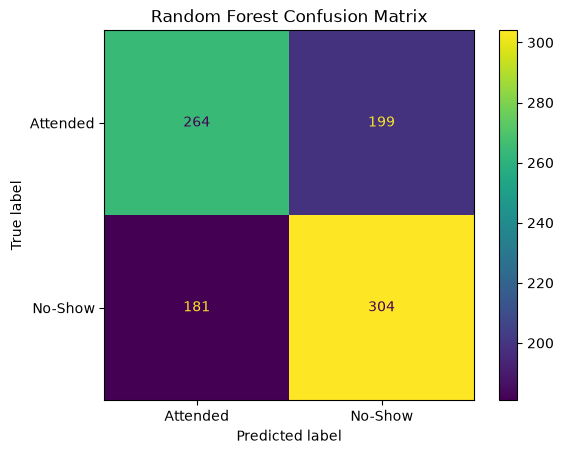

In [117]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test_refined, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                              display_labels=["Attended", "No-Show"])

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

### Interpretation
The Random Forest model produced 264 true negatives, 199 false positives, 181 false negatives, and 304 true positives on the test set. The model therefore correctly identified 304 of the actual No-Show appointments but missed 181 No-Show cases.

Compared with the refined Logistic Regression model, the Random Forest produced fewer false positives (199 compared with 216), indicating that it was somewhat less likely to incorrectly classify attended appointments as No-Shows. However, it also produced more false negatives (181 compared with 149) and fewer true positives (304 compared with 336). This means that the Random Forest missed more actual No-Show appointments.

These results are consistent with the lower recall of the Random Forest model (62.68%) compared with the refined Logistic Regression model (69.28%). Overall, the Random Forest did not provide a performance improvement on the current test set and therefore does not outperform the refined Logistic Regression model at this stage.


## 7.6 Final model comparison

In [127]:
model_comparison = pd.DataFrame({"Metric": ["Accuracy","Precision",
                                            "Recall","F1 Score","ROC-AUC"],
    "Refined Logistic Regression": [refined_accuracy, 
                                    refined_precision,
                                    refined_recall,
                                    refined_f1,
                                    refined_roc_auc],
    "Random Forest": [rf_accuracy,rf_precision,
                      rf_recall,rf_f1,rf_roc_auc]
})

model_comparison

,Metric,Refined Logistic Regression,Random Forest
0,Accuracy,0.614979,0.599156
1,Precision,0.608696,0.604374
2,Recall,0.692784,0.626804
3,F1 Score,0.648023,0.615385
4,ROC-AUC,0.664679,0.637441


### Interpretation and conclusion

The Random Forest model was developed using the same refined feature set as the Logistic Regression model to allow a fair comparison between the two approaches. The Random Forest achieved an accuracy of 59.92%, precision of 60.44%, recall of 62.68%, F1 Score of 61.54%, and ROC-AUC of 0.6374.

When compared with the refined Logistic Regression model, the Random Forest performed lower across all five evaluation metrics. The refined Logistic Regression achieved 61.50% accuracy, 60.87% precision, 69.28% recall, 64.80% F1 Score, and 0.6647 ROC-AUC.

The confusion matrices also showed that the Random Forest produced fewer false positives (199 compared with 216), but more false negatives (181 compared with 149). Therefore, although the Random Forest reduced the number of attended patients incorrectly classified as No-Shows, it missed more actual No-Show cases.

Overall, the Random Forest did not provide a performance improvement over the refined Logistic Regression model on the current test set. The refined Logistic Regression model therefore remains the stronger model at this stage, particularly because it achieved higher recall and F1 Score.

The Random Forest comparison demonstrates that increasing model complexity does not necessarily result in better predictive performance. The results will be carried forward into Step 8 for final model comparison, validation, and selection.


# 8. Compare and validate models

## 8.1 Final model comparison

The refined Logistic Regression and Random Forest models were compared using the same test dataset and the same evaluation metrics. This ensured that the comparison was based on a consistent evaluation procedure.

The refined Logistic Regression model achieved higher performance than the Random Forest model across all five metrics. It achieved an accuracy of 61.50%, precision of 60.87%, recall of 69.28%, F1 Score of 64.80%, and ROC-AUC of 0.6647.

The Random Forest model achieved an accuracy of 59.92%, precision of 60.44%, recall of 62.68%, F1 Score of 61.54%, and ROC-AUC of 0.6374.

The largest difference was observed in recall, where Logistic Regression achieved 69.28% compared with 62.68% for Random Forest. This is particularly relevant for the No-Show prediction task because a false negative represents a patient who was predicted to attend but actually did not attend.

Overall, the refined Logistic Regression model provided the stronger performance on the current test set.


## 8.2 Validate using cross-validation

In [138]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scoring = {"accuracy": "accuracy","precision": "precision",
           "recall": "recall","f1": "f1","roc_auc": "roc_auc"}

lr_cv_results = cross_validate(refined_logistic_model,X_refined,y_refined,
                               cv=cv, scoring=scoring,n_jobs=-1)

rf_cv_results = cross_validate(rf_pipeline,X_refined,y_refined,
                               cv=cv, scoring=scoring,n_jobs=-1)

print("Refined Logistic Regression - 5-Fold cross-validation")
print(f"Accuracy:  {lr_cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {lr_cv_results['test_precision'].mean():.4f}")
print(f"Recall:    {lr_cv_results['test_recall'].mean():.4f}")
print(f"F1 Score:  {lr_cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC:   {lr_cv_results['test_roc_auc'].mean():.4f}")

print("\nRandom Forest - 5-Fold cross-validation")
print(f"Accuracy:  {rf_cv_results['test_accuracy'].mean():.4f}")
print(f"Precision: {rf_cv_results['test_precision'].mean():.4f}")
print(f"Recall:    {rf_cv_results['test_recall'].mean():.4f}")
print(f"F1 Score:  {rf_cv_results['test_f1'].mean():.4f}")
print(f"ROC-AUC:   {rf_cv_results['test_roc_auc'].mean():.4f}")

Refined Logistic Regression - 5-Fold cross-validation
Accuracy:  0.6187
Precision: 0.6247
Recall:    0.6372
F1 Score:  0.6309
ROC-AUC:   0.6745

Random Forest - 5-Fold cross-validation
Accuracy:  0.6120
Precision: 0.6197
Recall:    0.6261
F1 Score:  0.6228
ROC-AUC:   0.6478


### Interpretation

Five-fold stratified cross-validation was performed to assess whether the observed difference between the refined Logistic Regression and Random Forest models was consistent across different subsets of the dataset.

The refined Logistic Regression model achieved mean cross-validation scores of 61.87% accuracy, 62.47% precision, 63.72% recall, 63.09% F1 Score, and 0.6745 ROC-AUC. The Random Forest model achieved 61.20% accuracy, 61.97% precision, 62.61% recall, 62.28% F1 Score, and 0.6478 ROC-AUC.

The refined Logistic Regression model achieved higher mean scores across all five evaluation metrics. In particular, its mean ROC-AUC was higher than that of Random Forest (0.6745 compared with 0.6478), indicating better overall discrimination between No-Show and Attended cases across the validation folds.

The cross-validation results therefore support the earlier test-set comparison and indicate that the refined Logistic Regression model provides more consistent predictive performance on the current dataset.


## 8.3 Final model selection

Based on the test-set evaluation and five-fold stratified cross-validation, the refined Logistic Regression model was selected as the preferred model for the HealthConnect Clinic No-Show prediction task.

The refined Logistic Regression model consistently outperformed the Random Forest model across the evaluation metrics. On the test set, it achieved 61.50% accuracy, 60.87% precision, 69.28% recall, 64.80% F1 Score, and 0.6647 ROC-AUC. In five-fold cross-validation, it achieved mean scores of 61.87% accuracy, 62.47% precision, 63.72% recall, 63.09% F1 Score, and 0.6745 ROC-AUC.

The model was preferred particularly because of its stronger recall and ROC-AUC performance. Higher recall is relevant to the No-Show prediction objective because false negatives represent actual No-Show cases that were not identified by the model.

Although the overall predictive performance remains moderate, the refined Logistic Regression model provides the strongest performance among the models evaluated in this project and is therefore selected as the final model.


## 8.4 Final validation and limitations

The final model evaluation indicates that the refined Logistic Regression model provides the strongest predictive performance among the models evaluated. However, the model should not be considered deployment-ready based on the current evaluation alone.

The test-set performance was moderate, with an accuracy of 61.50%, F1 Score of 64.80%, and ROC-AUC of 0.6647. The five-fold cross-validation produced a mean ROC-AUC of 0.6745, providing additional evidence that the model has some ability to distinguish between No-Show and Attended cases.

However, the model still produces both false positives and false negatives. In particular, the test-set confusion matrix contained 149 false negatives, meaning that some actual No-Show cases were not identified. The model should therefore be viewed as a decision-support tool rather than a replacement for clinic judgement.

The dataset is also synthetic, and the observed relationships should not be interpreted as causal. Further validation using real clinic data, temporal validation, additional feature engineering, probability calibration, and threshold optimisation would be required before considering operational use.


## 8.5 Final conclusion

Step 8 compared and validated the refined Logistic Regression and Random Forest models using a consistent test set and five-fold stratified cross-validation.

The refined Logistic Regression model achieved the strongest overall performance. On the test set, it achieved 61.50% accuracy, 60.87% precision, 69.28% recall, 64.80% F1 Score, and 0.6647 ROC-AUC. The Random Forest model achieved lower scores across all five metrics.

Five-fold cross-validation supported the same conclusion. The refined Logistic Regression model achieved mean scores of 61.87% accuracy, 62.47% precision, 63.72% recall, 63.09% F1 Score, and 0.6745 ROC-AUC, compared with 61.20%, 61.97%, 62.61%, 62.28%, and 0.6478 respectively for Random Forest.

The refined Logistic Regression model was therefore selected as the final model for the HealthConnect No-Show prediction task. The results demonstrate that the refined feature representation provided a modest improvement over the original baseline and that the more complex Random Forest model did not provide additional predictive benefit on the current dataset.

Overall, the project demonstrates a complete Data Science workflow from baseline modelling and error analysis through cross-track integration, feature refinement, non-linear model comparison, cross-validation, and final model selection. The final model provides a useful predictive baseline, while further validation and refinement would be required before deployment in a real clinical environment.
